Fraud Detection Project by Jordan Thompson

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
!pip install scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [34]:
df = pd.read_csv("credit_card_fraud_dataset.csv")

In [35]:
df.head()

,TransactionID,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud
0,1,2024-04-03 14:15:35.462794,4189.27,688,refund,San Antonio,0
1,2,2024-03-19 13:20:35.462824,2659.71,109,refund,Dallas,0
2,3,2024-01-08 10:08:35.462834,784.00,394,purchase,New York,0
3,4,2024-04-13 23:50:35.462850,3514.40,944,purchase,Philadelphia,0
4,5,2024-07-12 18:51:35.462858,369.07,475,purchase,Phoenix,0


In [36]:
df.info()
'Checking for data types'

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   TransactionID    100000 non-null  int64  
 1   TransactionDate  100000 non-null  str    
 2   Amount           100000 non-null  float64
 3   MerchantID       100000 non-null  int64  
 4   TransactionType  100000 non-null  str    
 5   Location         100000 non-null  str    
 6   IsFraud          100000 non-null  int64  
dtypes: float64(1), int64(3), str(3)
memory usage: 5.3 MB


'Checking for data types'

In [37]:
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   TransactionID    100000 non-null  int64         
 1   TransactionDate  100000 non-null  datetime64[us]
 2   Amount           100000 non-null  float64       
 3   MerchantID       100000 non-null  int64         
 4   TransactionType  100000 non-null  str           
 5   Location         100000 non-null  str           
 6   IsFraud          100000 non-null  int64         
dtypes: datetime64[us](1), float64(1), int64(3), str(2)
memory usage: 5.3 MB


Fraud vs Not Fraud Percentage


       TransactionID             TransactionDate         Amount  \
count  100000.000000                      100000  100000.000000   
mean    50000.500000  2024-04-21 13:06:09.973745    2497.092666   
min         1.000000  2023-10-21 09:28:35.824439       1.050000   
25%     25000.750000  2024-01-20 23:18:20.586056    1247.955000   
50%     50000.500000  2024-04-21 13:39:35.701439    2496.500000   
75%     75000.250000  2024-07-21 22:28:05.702624    3743.592500   
max    100000.000000  2024-10-21 09:20:35.961088    4999.770000   
std     28867.657797                         NaN    1442.415999   

          MerchantID        IsFraud  
count  100000.000000  100000.000000  
mean      501.676070       0.010000  
min         1.000000       0.000000  
25%       252.000000       0.000000  
50%       503.000000       0.000000  
75%       753.000000       0.000000  
max      1000.000000       1.000000  
std       288.715868       0.099499  


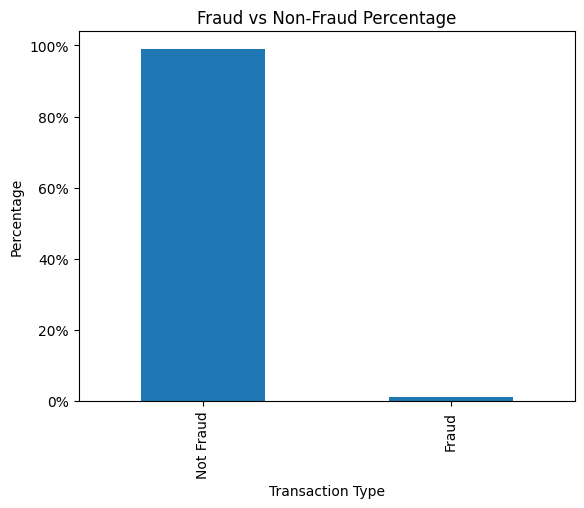

In [38]:

print(df.describe())
fraud_counts = df["IsFraud"].replace({0: "Not Fraud", 1: "Fraud"})

ax = (fraud_counts
        .value_counts(normalize=True)
        .mul(100)
        .plot(kind="bar"))

plt.title("Fraud vs Non-Fraud Percentage")

plt.xlabel("Transaction Type")

plt.ylabel("Percentage")

ax.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.show()


Fraud Rate by Transaction Type

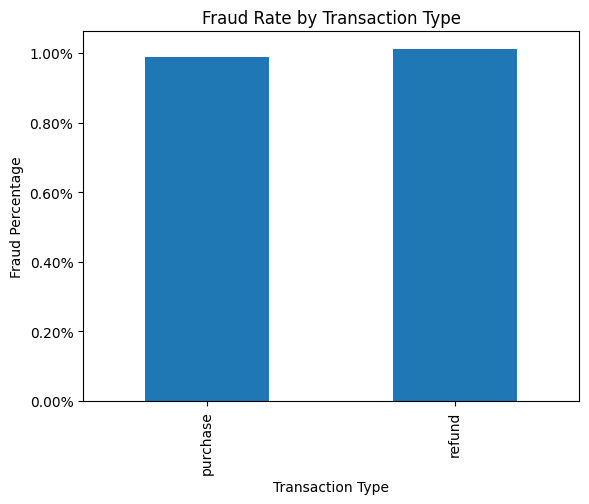

In [39]:

ax = (df.groupby("TransactionType")["IsFraud"].mean() * 100).plot(kind="bar")

plt.title("Fraud Rate by Transaction Type")

plt.xlabel("Transaction Type")

plt.ylabel("Fraud Percentage")

ax.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.show()

Fraud Frequency by Hour

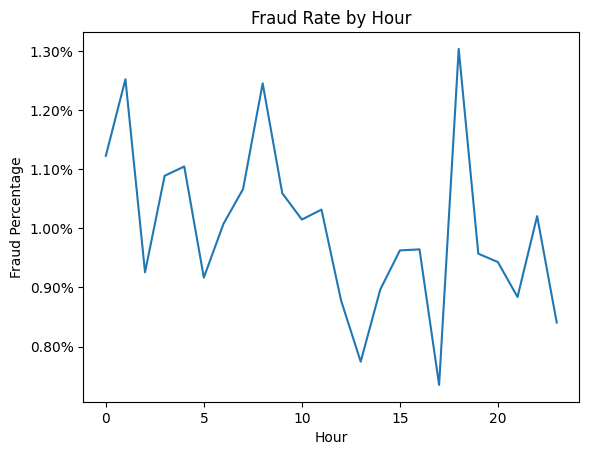

In [40]:
df["Hour"] = df["TransactionDate"].dt.hour

df.groupby("Hour")["IsFraud"].mean() * 100

ax = (df.groupby("Hour")["IsFraud"].mean() * 100).plot(kind="line")

plt.title("Fraud Rate by Hour")

plt.xlabel("Hour")

plt.ylabel("Fraud Percentage")

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))

plt.show()

Highest Fraud Rates by Location

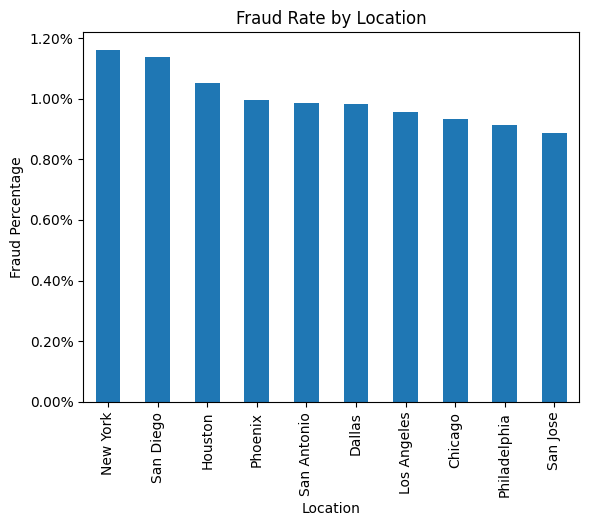

In [41]:
df.groupby("Location")["IsFraud"].mean() * 100

(df.groupby("Location")["IsFraud"].mean() * 100).sort_values(ascending=False)

ax = ((df.groupby("Location")["IsFraud"].mean() * 100)
        .sort_values(ascending=False)
        .plot(kind="bar"))

plt.title("Fraud Rate by Location")

plt.xlabel("Location")

plt.ylabel("Fraud Percentage")

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))

plt.show()

Creating a Predictor for Fraud

In [42]:
'Using inputs to make predictions'
df_encoded = pd.get_dummies(
    df,
    columns=["TransactionType", "Location"],
    drop_first=True
)

features = df_encoded.drop(
    columns=["IsFraud", "TransactionDate"]
)

target = df_encoded["IsFraud"]

In [43]:
'Training and Testing Data'
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

In [44]:
'Training Model'
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [45]:
'Making Predictions'
predictions = model.predict(X_test)

In [46]:
'Evaluating Model'
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     19787
           1       0.00      0.00      0.00       213

    accuracy                           0.99     20000
   macro avg       0.49      0.50      0.50     20000
weighted avg       0.98      0.99      0.98     20000



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

Displaying the Success of the Prediction Model

In [47]:
'Confusion Matrix'
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

print(cm)

[[19787     0]
 [  213     0]]


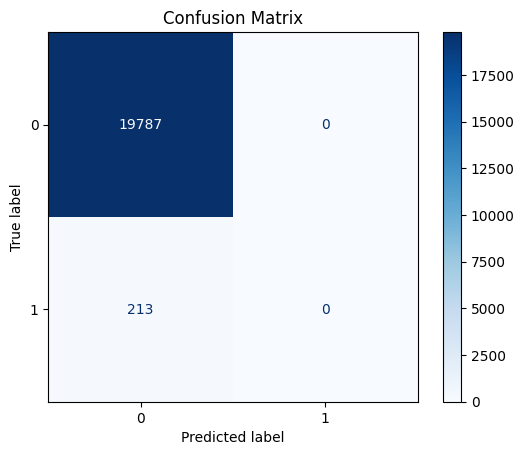

'This highlights a common challenge in fraud detection systems: balancing fraud recall with minimizing false positives.'

In [48]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    cmap="Blues",
    values_format=".0f"
)
'Displaying Model Chart'
plt.title("Confusion Matrix")
plt.show()

'Model Evaluation: The dataset was highly imbalanced, with fraudulent transactions representing a very small percentage of total observations. As a result, the Random Forest model achieved high overall accuracy by primarily predicting non-fraudulent transactions.'
'This highlights a common challenge in fraud detection systems: balancing fraud recall with minimizing false positives.'

In [50]:
df.to_csv("fraud_dashboard_data.csv", index=False)